# "Customer Churn Prediction — Multi-Algorithm Classification Showdown"

# Step 1: Problem Framing & Theory Notes

## 1. What is Customer Churn? Why is predicting churn valuable for a business like Jio or Airtel? (Mention CAC vs CLV)

**Customer Churn** is the process where existing customers stop using a company's product or service. In the telecom industry, churn occurs when customers switch from one service provider (e.g., Jio, Airtel, Vi) to another.

Predicting customer churn helps businesses identify customers who are likely to leave so they can take preventive actions such as offering discounts, better plans, loyalty rewards, or personalized support.

### CAC vs CLV
- **CAC (Customer Acquisition Cost):** The cost incurred to acquire a new customer through marketing, advertising, and sales efforts.
- **CLV (Customer Lifetime Value):** The total revenue a customer is expected to generate during their relationship with the company.

Since acquiring a new customer (CAC) is much more expensive than retaining an existing one, predicting churn helps increase CLV, reduce revenue loss, and improve customer satisfaction.

---

## 2. Define the four cells of a Confusion Matrix (TP, TN, FP, FN). In the churn context, what is the business cost of a False Negative? What about a False Positive?

A **Confusion Matrix** is used to evaluate the performance of a classification model.

| Term | Meaning in Churn Prediction |
|------|------------------------------|
| **True Positive (TP)** | Customer was predicted to churn and actually churned. |
| **True Negative (TN)** | Customer was predicted to stay and actually stayed. |
| **False Positive (FP)** | Customer was predicted to churn but actually stayed. |
| **False Negative (FN)** | Customer was predicted to stay but actually churned. |

### Business Cost

- **False Negative (FN):**
  - High business cost.
  - The company fails to identify a customer who leaves.
  - Results in loss of revenue, higher future CAC, and reduced customer lifetime value.

- **False Positive (FP):**
  - Moderate business cost.
  - The company offers discounts or retention benefits to a customer who would have stayed anyway.
  - Leads to unnecessary marketing expenses.

---

## 3. What is Class Imbalance? Does the Telco Churn dataset have it? How does SMOTE address it?

**Class Imbalance** occurs when one class has significantly more samples than another.

In the **Telco Customer Churn** dataset:
- Customers who **did not churn** are much more than customers who **did churn**.
- Therefore, the dataset is **imbalanced**.

### How SMOTE Works

**SMOTE (Synthetic Minority Over-sampling Technique)** balances the dataset by generating synthetic examples of the minority class instead of simply duplicating existing records.

### Advantages
- Balances the dataset.
- Reduces model bias toward the majority class.
- Improves Recall and F1-score.
- Helps classifiers learn minority-class patterns more effectively.

---

## 4. Briefly explain how each algorithm works (KNN, Naive Bayes, SVM, Decision Tree)

### K-Nearest Neighbors (KNN)
KNN is an instance-based learning algorithm that classifies a new data point based on the majority class of its **K nearest neighbors** using a distance metric such as Euclidean distance.

### Naive Bayes
Naive Bayes is a probabilistic classifier based on **Bayes' Theorem**. It assumes that all features are independent and predicts the class with the highest posterior probability.

### Support Vector Machine (SVM)
SVM finds the **optimal hyperplane** that best separates different classes by maximizing the margin between them. It can also classify non-linear data using kernel functions.

### Decision Tree
A Decision Tree recursively splits the dataset using the feature that provides the highest information gain (or lowest Gini impurity). The final prediction is made at the leaf node.

---

## 5. When would you choose Precision over Recall as your primary metric? Give a churn-specific answer.

**Precision** should be chosen when the cost of **False Positives** is high.

In customer churn prediction, if the company provides expensive retention offers (cashbacks, free plans, premium subscriptions), it should ensure that only customers who are truly likely to churn receive those offers.

High Precision means:
- Fewer unnecessary retention offers.
- Reduced marketing costs.
- Better utilization of promotional budgets.

However, in many churn prediction problems, **Recall** is often preferred because missing an actual churn customer (False Negative) results in customer loss and reduced revenue.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")


# step 2: Dataset Loading & Exploratory Data Analysis
## 2.1  Load & Inspect

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print(df.shape)
print(df.info())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
print(df.describe(include='all'))


        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     3186-AJIEK   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  ...  \
count         

In [5]:
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [6]:
# ----------------------------
# TotalCharges Investigation
# ----------------------------

print("\n" + "="*60)
print("Data Type Before Conversion")
print("="*60)
print(df["TotalCharges"].dtype)

# Replace blanks with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

print("\nData Type After Conversion")
print(df["TotalCharges"].dtype)

# Missing values
print("\nMissing Values in TotalCharges")
print(df["TotalCharges"].isnull().sum())

# Remove missing rows
df.dropna(inplace=True)

print("\nDataset Shape After Removing Missing Values")
print(df.shape)




Data Type Before Conversion
object

Data Type After Conversion
float64

Missing Values in TotalCharges
11

Dataset Shape After Removing Missing Values
(7032, 21)


In [7]:
# ----------------------------
# Class Balance
# ----------------------------

print("\n" + "="*60)
print("Class Distribution")
print("="*60)

print(df["Churn"].value_counts())

print("\nPercentage Distribution")
print(df["Churn"].value_counts(normalize=True) * 100)

churn_percent = df["Churn"].value_counts(normalize=True)["Yes"] * 100

print(f"\nCustomers Churned : {churn_percent:.2f}%")

if churn_percent < 40:
    print("Conclusion : The dataset is IMBALANCED.")
else:
    print("Conclusion : The dataset is BALANCED.")


Class Distribution
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage Distribution
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

Customers Churned : 26.58%
Conclusion : The dataset is IMBALANCED.


## 2.2  Univariate Analysis


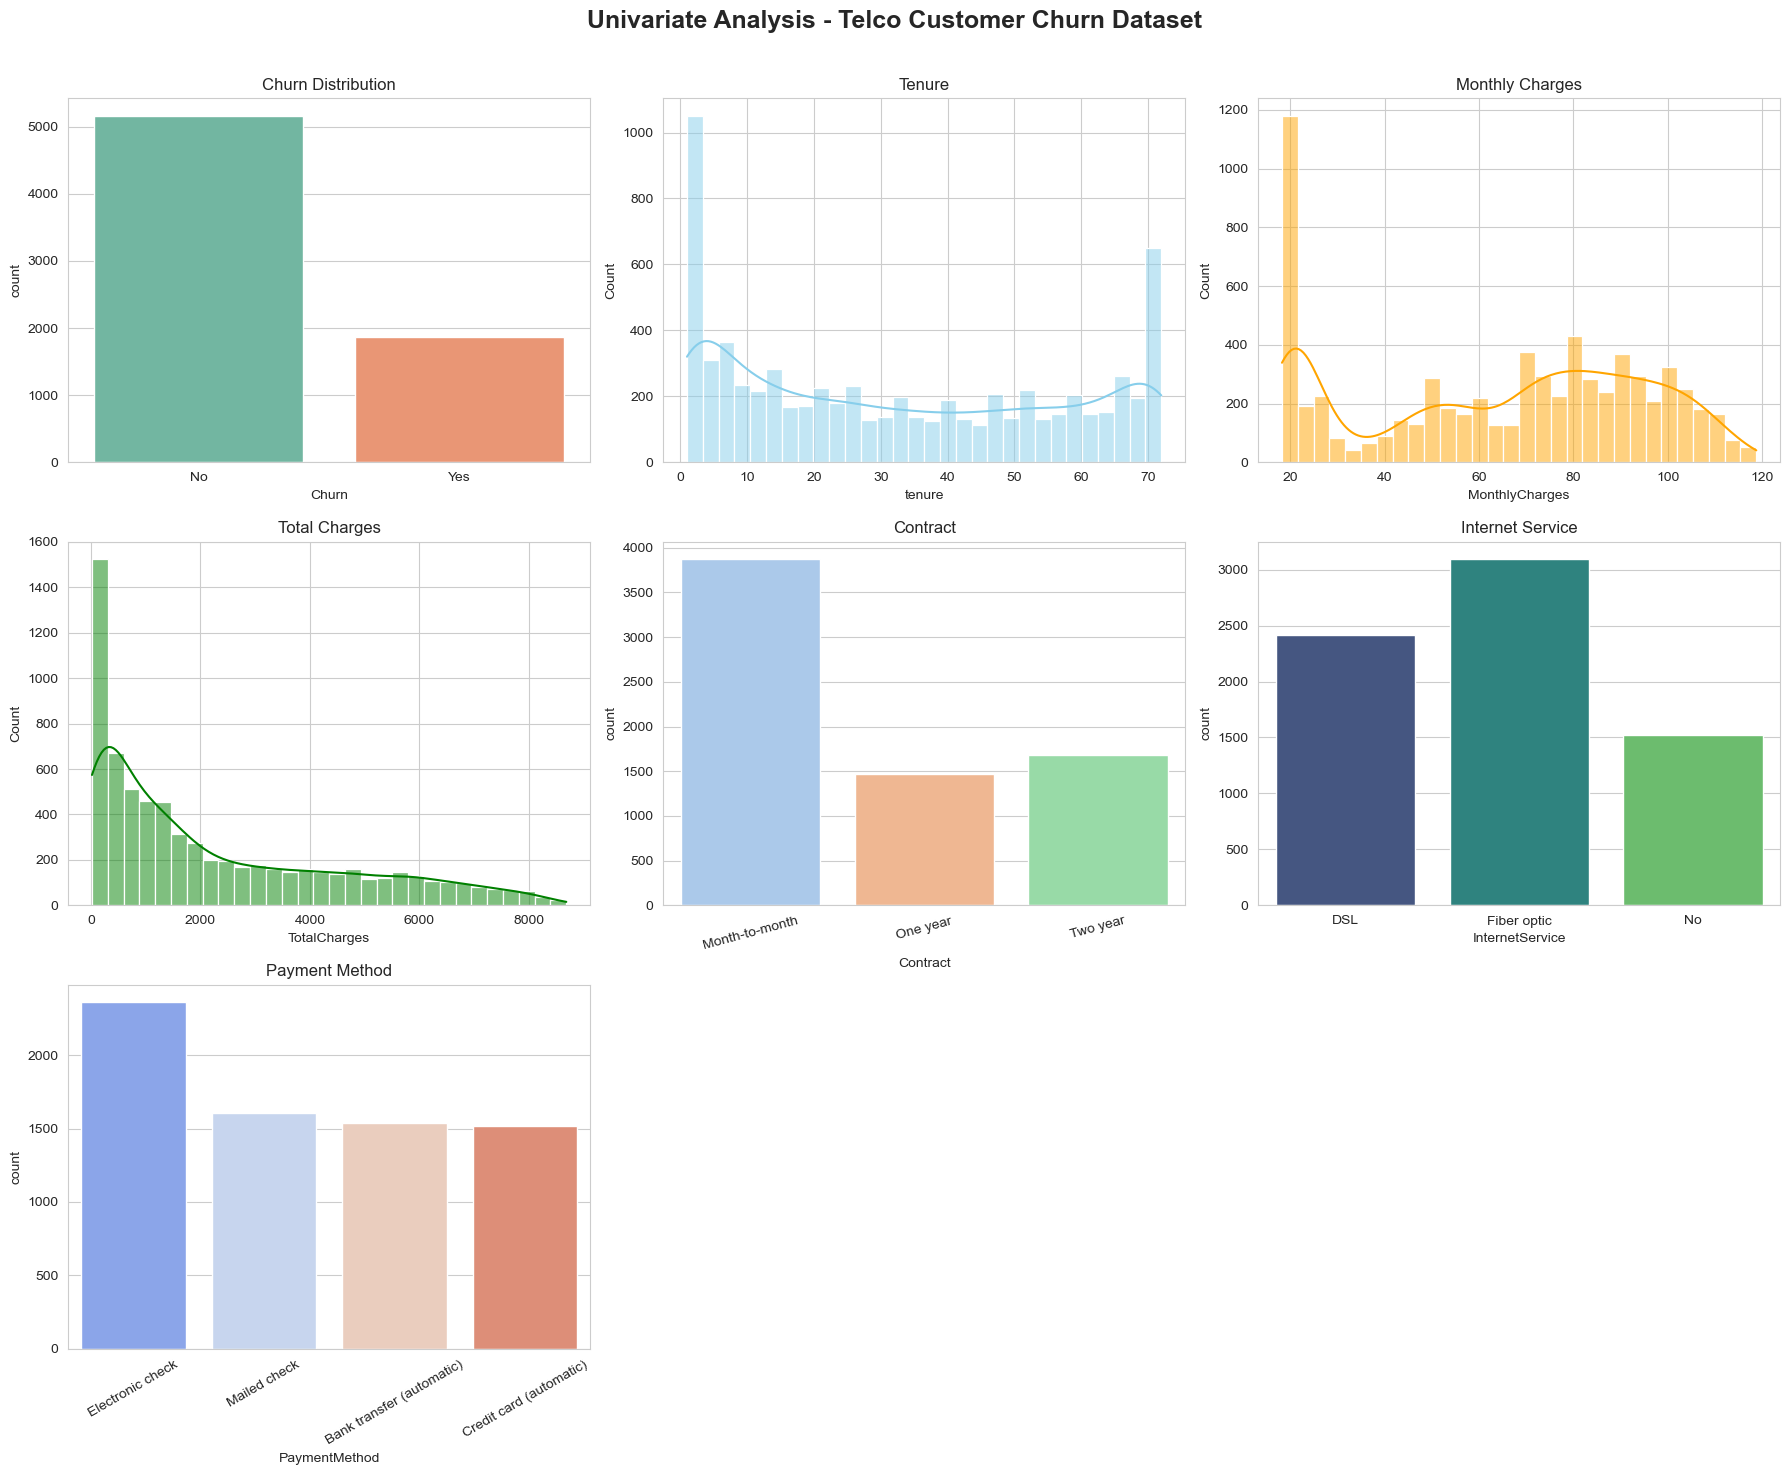

In [8]:


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Univariate Analysis - Telco Customer Churn Dataset",
             fontsize=18, fontweight="bold")

# -----------------------------
# 1. Churn Countplot
# -----------------------------
sns.countplot(data=df, x="Churn", ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Churn Distribution")

# -----------------------------
# 2. Tenure Histogram
# -----------------------------
sns.histplot(df["tenure"], bins=30, kde=True,
             ax=axes[0,1], color="skyblue")
axes[0,1].set_title("Tenure")

# -----------------------------
# 3. Monthly Charges Histogram
# -----------------------------
sns.histplot(df["MonthlyCharges"], bins=30, kde=True,
             ax=axes[0,2], color="orange")
axes[0,2].set_title("Monthly Charges")

# -----------------------------
# 4. Total Charges Histogram
# -----------------------------
sns.histplot(df["TotalCharges"], bins=30, kde=True,
             ax=axes[1,0], color="green")
axes[1,0].set_title("Total Charges")

# -----------------------------
# 5. Contract Countplot
# -----------------------------
sns.countplot(data=df, x="Contract",
              ax=axes[1,1], palette="pastel")
axes[1,1].set_title("Contract")
axes[1,1].tick_params(axis='x', rotation=15)

# -----------------------------
# 6. Internet Service Countplot
# -----------------------------
sns.countplot(data=df, x="InternetService",
              ax=axes[1,2], palette="viridis")
axes[1,2].set_title("Internet Service")

# -----------------------------
# 7. Payment Method Countplot
# -----------------------------
sns.countplot(data=df, x="PaymentMethod",
              ax=axes[2,0], palette="coolwarm")
axes[2,0].set_title("Payment Method")
axes[2,0].tick_params(axis='x', rotation=30)

# -----------------------------
# Remove Empty Subplots
# -----------------------------
fig.delaxes(axes[2,1])
fig.delaxes(axes[2,2])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Step 2.3 : Bivariate Analysis


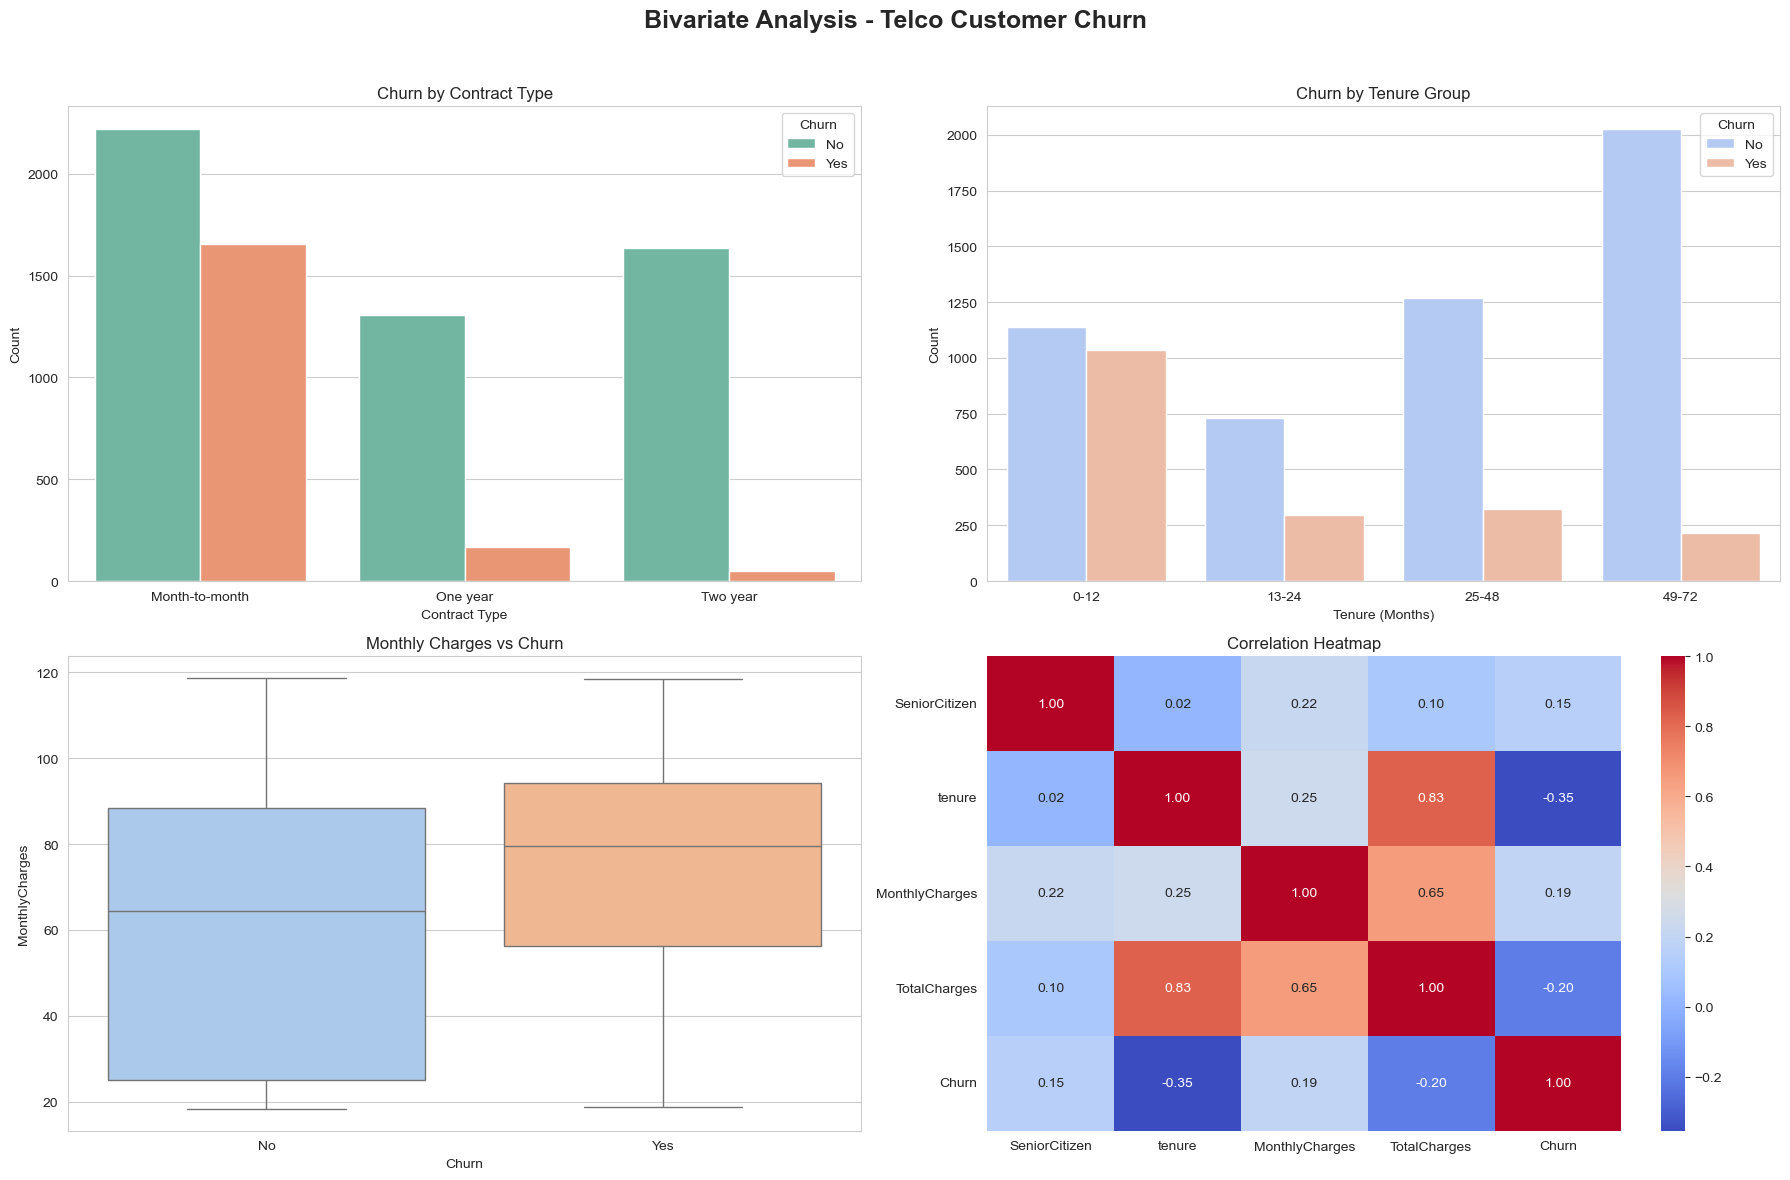

In [9]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# ---------------------------------
# Create Tenure Buckets
# ---------------------------------
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

# ---------------------------------
# Create Figure
# ---------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Bivariate Analysis - Telco Customer Churn",
             fontsize=18, fontweight="bold")

# =====================================
# 1. Churn Rate by Contract
# =====================================
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2",
    ax=axes[0,0]
)
axes[0,0].set_title("Churn by Contract Type")
axes[0,0].set_xlabel("Contract Type")
axes[0,0].set_ylabel("Count")

# =====================================
# 2. Churn Rate by Tenure Bucket
# =====================================
sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn",
    palette="coolwarm",
    ax=axes[0,1]
)
axes[0,1].set_title("Churn by Tenure Group")
axes[0,1].set_xlabel("Tenure (Months)")
axes[0,1].set_ylabel("Count")

# =====================================
# 3. Monthly Charges vs Churn
# =====================================
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="pastel",
    ax=axes[1,0]
)
axes[1,0].set_title("Monthly Charges vs Churn")

# =====================================
# 4. Correlation Heatmap
# =====================================

# Convert target into numeric temporarily
temp = df.copy()
temp["Churn"] = temp["Churn"].map({"No":0,"Yes":1})

corr = temp[["SeniorCitizen",
             "tenure",
             "MonthlyCharges",
             "TotalCharges",
             "Churn"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1,1]
)

axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

# Step 3: Data Preprocessing & Feature Engineering


## 3.1  Drop & Clean

In [10]:
# Drop customerID
df.drop("customerID", axis=1, inplace=True)

# Replace blanks with NaN and convert to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan))

# Fill missing values with median
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Check
print(df.isnull().sum())
print(df.dtypes["TotalCharges"])

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
TenureGroup         0
dtype: int64
float64


## 3.2  Feature Engineering

In [11]:
# Tenure Group
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 36, 60, float("inf")],
    labels=["New", "Mid", "Senior", "Loyal"],
    include_lowest=True
)

# Number of Services
services = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

df["num_services"] = (df[services] == "Yes").sum(axis=1)

# AutoPay Feature
df["AutoPay"] = df["PaymentMethod"].str.contains("automatic", case=False).astype(int)

# Check
df[["tenure_group", "num_services", "AutoPay"]].head()

,tenure_group,num_services,AutoPay
0,New,1,0
1,Mid,2,0
2,New,2,0
3,Senior,3,1
4,New,0,0


## 3.3  Encoding

In [12]:
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Binary Encoding (Yes=1, No=0)
# -----------------------------
binary_cols = [
    "Partner", "Dependents", "PhoneService",
    "PaperlessBilling", "Churn"
]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# -----------------------------
# Label Encoding (Ordinal)
# -----------------------------
le = LabelEncoder()
df["tenure_group"] = le.fit_transform(df["tenure_group"])

# Order:
# New = 0
# Mid = 1
# Senior = 2
# Loyal = 3

# -----------------------------
# One-Hot Encoding
# -----------------------------
df = pd.get_dummies(
    df,
    columns=["InternetService", "Contract", "PaymentMethod"],
    drop_first=True,
    dtype=int
)

# Check
print(df.head())
print(df.shape)

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0  Female              0        1           0       1             0   
1    Male              0        0           0      34             1   
2    Male              0        0           0       2             1   
3    Male              0        0           0      45             0   
4  Female              0        0           0       2             1   

      MultipleLines OnlineSecurity OnlineBackup DeviceProtection  ...  \
0  No phone service             No          Yes               No  ...   
1                No            Yes           No              Yes  ...   
2                No            Yes          Yes               No  ...   
3  No phone service            Yes           No              Yes  ...   
4                No             No           No               No  ...   

  tenure_group num_services AutoPay  InternetService_Fiber optic  \
0            2            1       0                            0  

## 3.4  Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,tenure_group,num_services,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Female,0,1,0,-1.280248,0,No phone service,No,Yes,No,...,2,-0.562044,0,0,0,0,0,0,1,0
1,Male,0,0,0,0.064303,1,No,Yes,No,Yes,...,1,-0.020634,0,0,0,1,0,0,0,1
2,Male,0,0,0,-1.239504,1,No,Yes,Yes,No,...,2,-0.020634,0,0,0,0,0,0,0,1
3,Male,0,0,0,0.512486,0,No phone service,Yes,No,Yes,...,3,0.520776,1,0,0,1,0,0,0,0
4,Female,0,0,0,-1.239504,1,No,No,No,No,...,2,-1.103454,0,1,0,0,0,0,1,0


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = [
    "gender",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in cols:
    df[col] = le.fit_transform(df[col])

# Verify
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [16]:
# Drop the categorical TenureGroup column
df.drop(columns=["TenureGroup"], inplace=True)

# Verify
print(df.dtypes)

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                   float64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
tenure_group                               int64
num_services                             float64
AutoPay                                    int64
InternetService_Fibe

## 3.5  Handle Class Imbalance
## 3.6  Train-Test Split


In [60]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# ==========================================
# Step 3.6 : Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train-Test Split")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)



Train-Test Split
X_train : (5625, 26)
X_test  : (1407, 26)
y_train : (5625,)
y_test  : (1407,)


In [59]:
# ==========================================
# Step 3.5 : Handle Class Imbalance (SMOTE)
# ==========================================

print("\nClass Count Before SMOTE")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nClass Count After SMOTE")
print(y_train.value_counts())


Class Count Before SMOTE
Churn
0    4130
1    4130
Name: count, dtype: int64

Class Count After SMOTE
Churn
0    4130
1    4130
Name: count, dtype: int64


# Step 4: Model Building — KNN & Naive Bayes

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.7164179104477612
Precision: 0.47810858143607704
Recall   : 0.7299465240641712
F1 Score : 0.5777777777777777
ROC AUC  : 0.7738609832738869


## 4.1  K-Nearest Neighbours (KNN)

Best k = 15


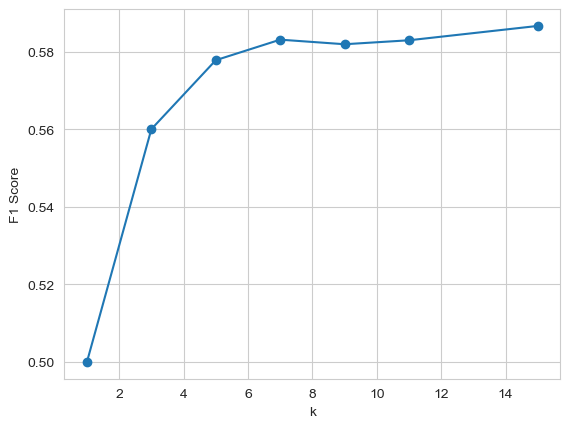

In [19]:
import matplotlib.pyplot as plt

k_list=[1,3,5,7,9,11,15]
f1=[]

for k in k_list:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    f1.append(f1_score(y_test,pred))

best_k=k_list[f1.index(max(f1))]
print("Best k =",best_k)

plt.plot(k_list,f1,marker='o')
plt.xlabel("k")
plt.ylabel("F1 Score")
plt.show()

In [20]:
knn=KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

y_pred=knn.predict(X_test)
y_prob=knn.predict_proba(X_test)[:,1]


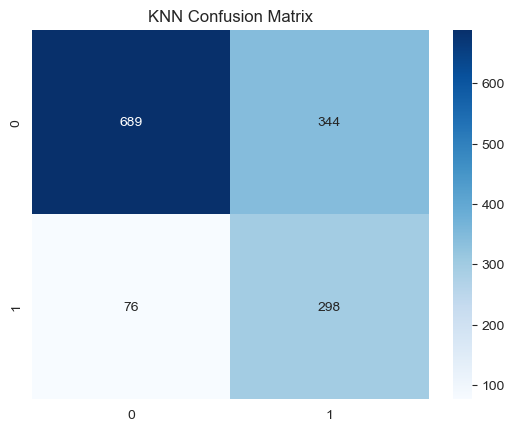

In [21]:
import seaborn as sns

cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

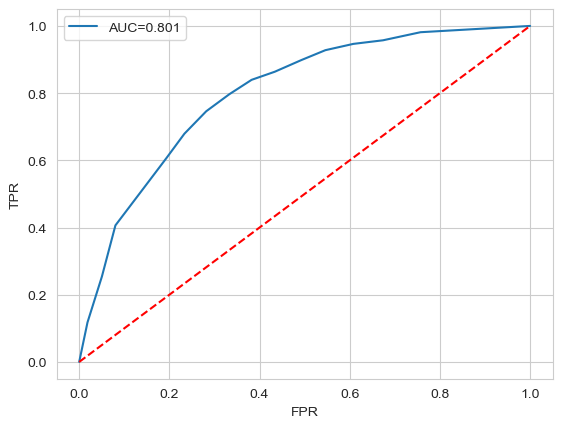

In [22]:
fpr,tpr,_=roc_curve(y_test,y_prob)

plt.plot(fpr,tpr,label="AUC=%.3f"%roc_auc_score(y_test,y_prob))
plt.plot([0,1],[0,1],'r--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

## 4.2  Naive Bayes — Gaussian NB

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import *

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
y_prob = nb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7377398720682303
Precision: 0.5043936731107206
Recall   : 0.767379679144385
F1 Score : 0.6086956521739131
ROC AUC  : 0.8129597610407359


In [24]:
print("Class Prior:", nb.class_prior_)

print("\nActual Churn Rate:")
print(y_train.value_counts(normalize=True))

Class Prior: [0.5 0.5]

Actual Churn Rate:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


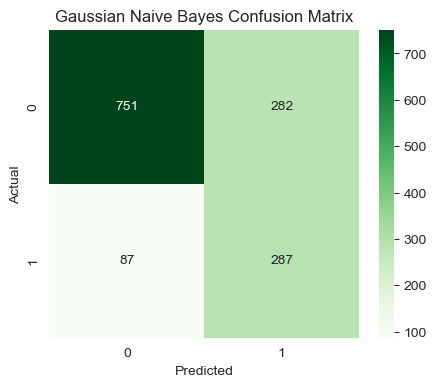

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

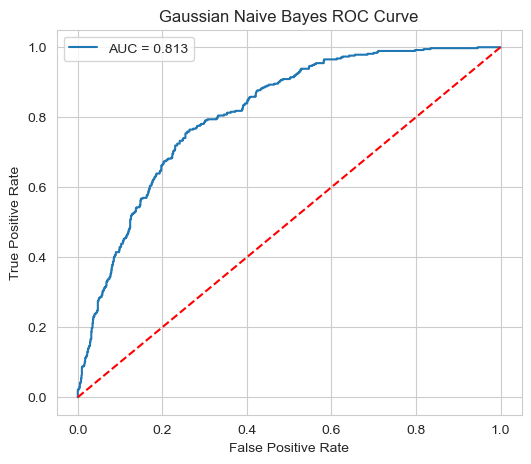

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gaussian Naive Bayes ROC Curve")
plt.legend()
plt.show()

# Step 5: Model Building — SVM & Decision Tree
## 5.1  Support Vector Machine (SVM)


In [31]:
from sklearn.svm import SVC
from sklearn.metrics import *

svm = SVC(kernel='rbf', C=1, gamma='scale',
          probability=True, random_state=42)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.7555081734186212
Precision: 0.5298804780876494
Recall   : 0.7112299465240641
F1 Score : 0.6073059360730594
ROC AUC  : 0.8066234062048652


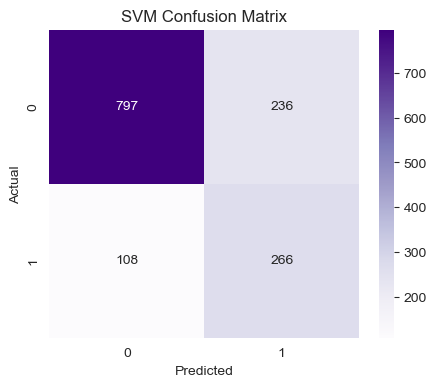

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
from sklearn.model_selection import cross_val_score

C_values = [0.1, 1, 10, 100]
scores = []

for c in C_values:
    model = SVC(kernel='rbf',
                C=c,
                gamma='scale',
                probability=True,
                random_state=42)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="f1"
    ).mean()

    scores.append(score)

best_C = C_values[scores.index(max(scores))]
print("Best C =", best_C)      

Best C = 10


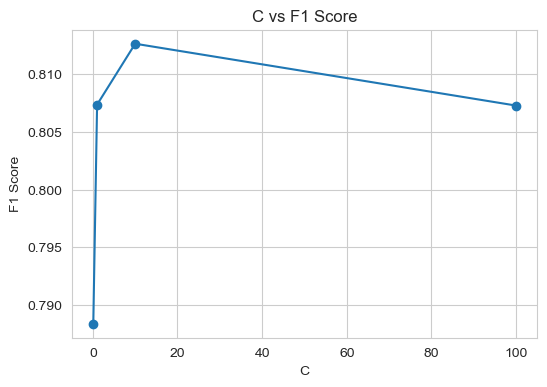

In [34]:
plt.figure(figsize=(6,4))
plt.plot(C_values, scores, marker='o')
plt.xlabel("C")
plt.ylabel("F1 Score")
plt.title("C vs F1 Score")
plt.grid(True)
plt.show()

In [35]:
svm = SVC(kernel='rbf',
          C=best_C,
          gamma='scale',
          probability=True,
          random_state=42)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.757640369580668
Precision: 0.5361050328227571
Recall   : 0.6550802139037433
F1 Score : 0.5896510228640193
ROC AUC  : 0.7840501421020752


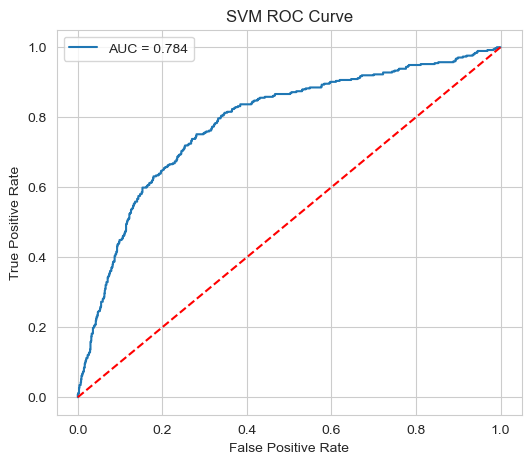

In [36]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")

plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

## 5.2  Decision Tree Classifier

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.7270788912579957
Precision: 0.4912891986062718
Recall   : 0.7540106951871658
F1 Score : 0.5949367088607594
ROC AUC  : 0.8072614419348659


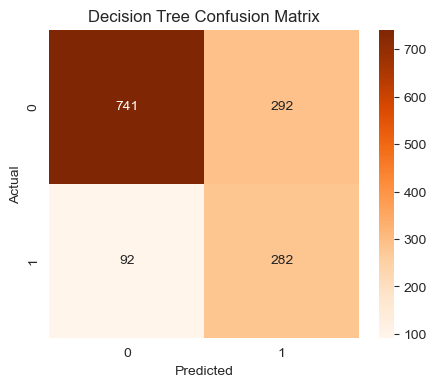

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Oranges")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

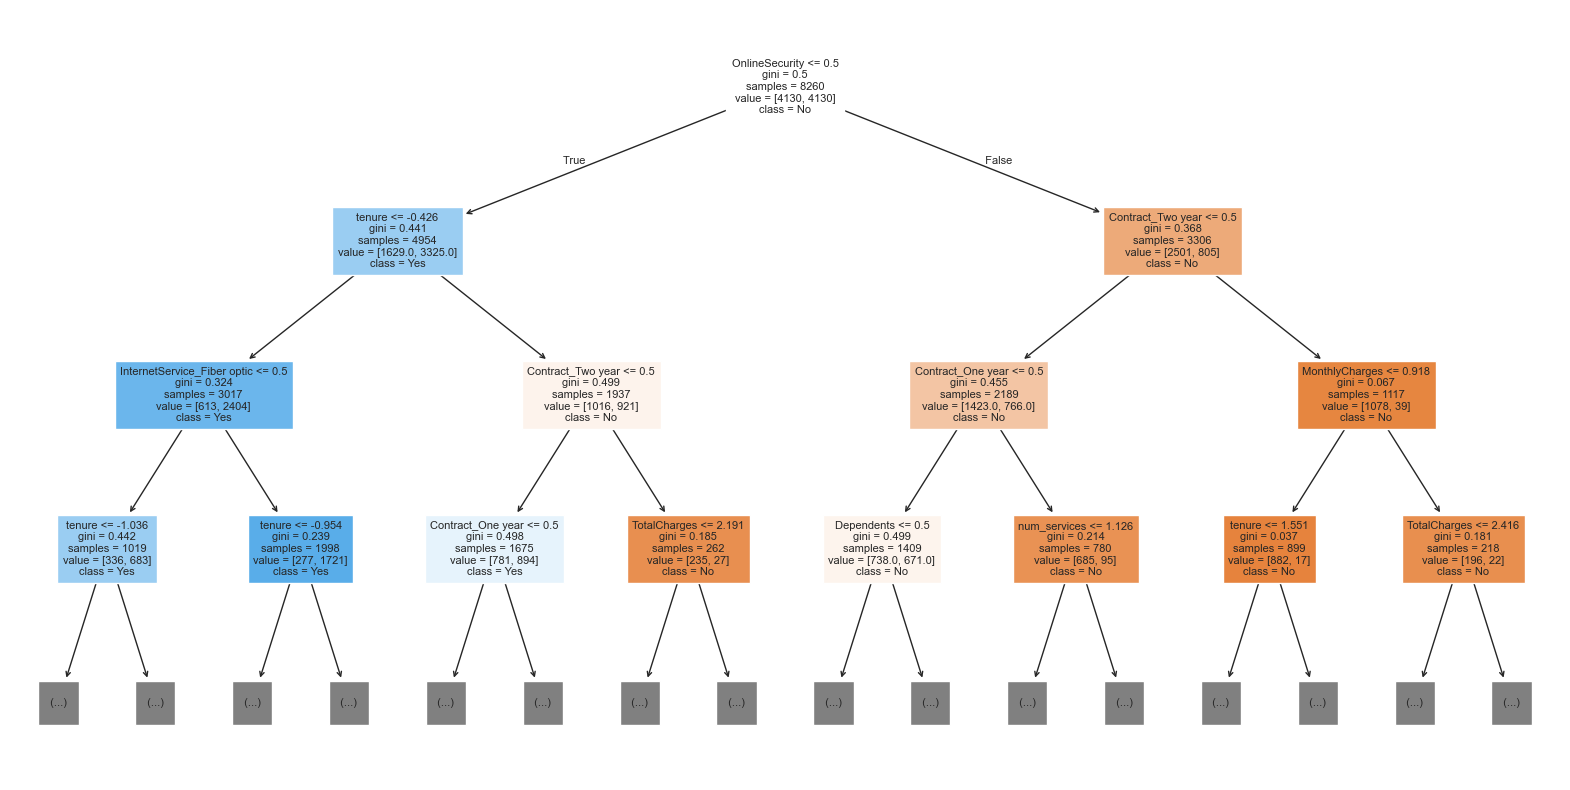

In [39]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["No","Yes"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

In [40]:
from sklearn.model_selection import cross_val_score

depths = [3,4,5,6,7,8,None]
scores = []

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        class_weight="balanced",
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="f1"
    ).mean()

    scores.append(score)

best_depth = depths[scores.index(max(scores))]

print("Best Depth =", best_depth)

Best Depth = 8


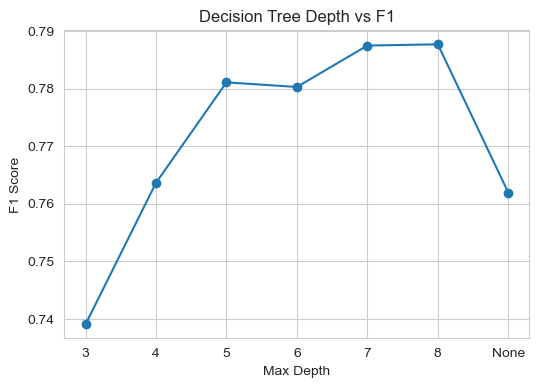

In [41]:
plt.figure(figsize=(6,4))

plt.plot(
    [str(i) for i in depths],
    scores,
    marker="o"
)

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Decision Tree Depth vs F1")
plt.grid(True)
plt.show()

In [42]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

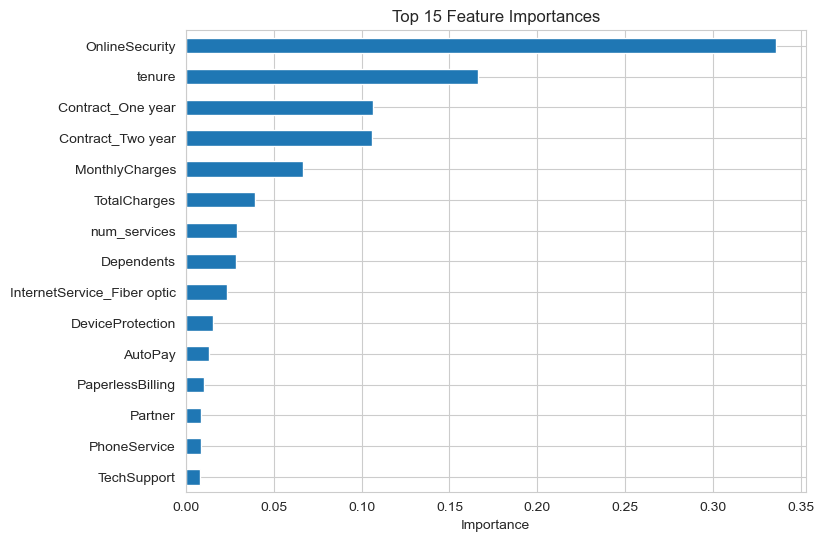

In [43]:
import pandas as pd

importance = pd.Series(
    dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))

importance.sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score

# Model trained on SMOTE data
dt_smote = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_smote.fit(X_train, y_train)

pred_smote = dt_smote.predict(X_test)

recall_smote = recall_score(y_test, pred_smote)

print("Recall (SMOTE):", recall_smote)

Recall (SMOTE): 0.7005347593582888


In [45]:
# Original train data (without SMOTE)
X_train_org, X_test_org, y_train_org, y_test_org = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

dt_balanced = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

dt_balanced.fit(X_train_org, y_train_org)

pred_balanced = dt_balanced.predict(X_test_org)

recall_balanced = recall_score(y_test_org, pred_balanced)

print("Recall (Balanced):", recall_balanced)

Recall (Balanced): 0.7433155080213903


## 5.3  One Model with class_weight='balanced' vs SMOTE


In [46]:
print("\nComparison")
print("SMOTE Recall           :", recall_smote)
print("Balanced Recall        :", recall_balanced)

if recall_smote > recall_balanced:
    print("\nSMOTE gives better Recall.")
elif recall_balanced > recall_smote:
    print("\nclass_weight='balanced' gives better Recall.")
else:
    print("\nBoth approaches give the same Recall.")


Comparison
SMOTE Recall           : 0.7005347593582888
Balanced Recall        : 0.7433155080213903

class_weight='balanced' gives better Recall.


In [47]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

# All trained models
models = {
    "KNN": knn,
    "Naive Bayes": nb,
    "SVM": svm,
    "Decision Tree": dt
}

results = []

for name, model in models.items():

    start = time.time()

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    train_time = time.time() - start

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test,y_pred),3),
        "Precision": round(precision_score(y_test,y_pred),3),
        "Recall": round(recall_score(y_test,y_pred),3),
        "F1-Score": round(f1_score(y_test,y_pred),3),
        "AUC-ROC": round(roc_auc_score(y_test,y_prob),3),
        "Training Time (s)": round(train_time,4)
    })

results = pd.DataFrame(results)
results = results.sort_values("Recall",ascending=False)

results

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (s)
0,KNN,0.701,0.464,0.797,0.587,0.801,0.1214
1,Naive Bayes,0.738,0.504,0.767,0.609,0.813,0.0033
3,Decision Tree,0.733,0.498,0.701,0.582,0.782,0.0052
2,SVM,0.758,0.536,0.655,0.590,0.784,0.8799


# Step 6: Model Evaluation & Comparison

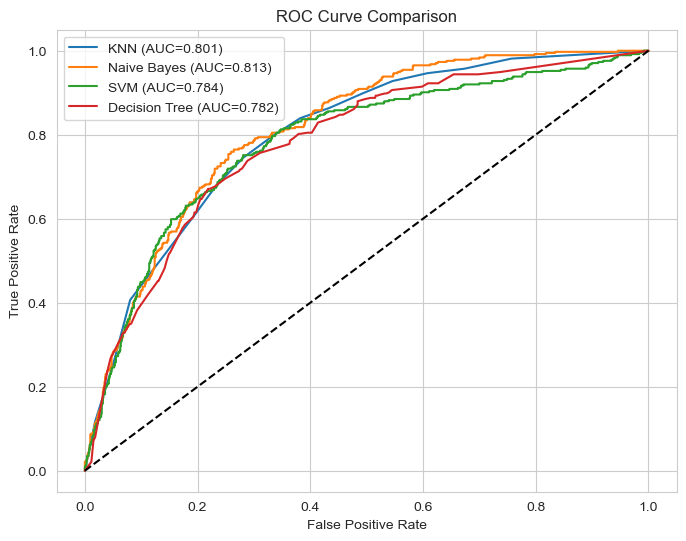

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr,tpr,_ = roc_curve(y_test,y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc_score(y_test,y_prob):.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

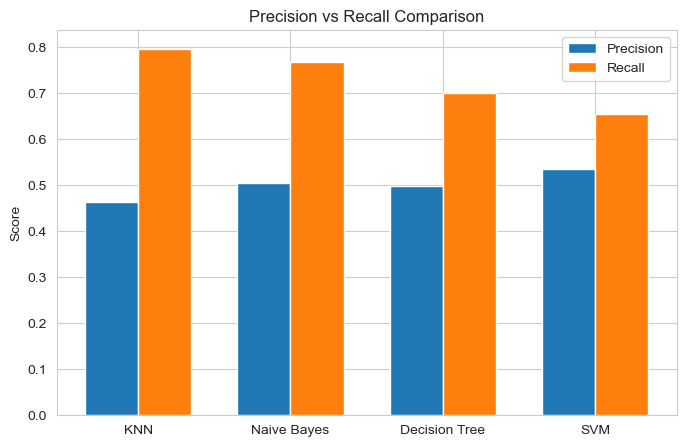

In [49]:
import numpy as np

x=np.arange(len(results))

width=0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2,results["Precision"],width,label="Precision")
plt.bar(x+width/2,results["Recall"],width,label="Recall")

plt.xticks(x,results["Model"])

plt.ylabel("Score")
plt.title("Precision vs Recall Comparison")

plt.legend()

plt.show()

# Step 7: Error Analysis & Interpretation
## 7.1  Error Analysis on Best Model


In [50]:
import pandas as pd

# Predict using best model
y_pred = dt.predict(X_test)

# Test data with actual & predicted values
error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = y_pred

# False Negatives
fn = error_df[(error_df["Actual"]==1) & (error_df["Predicted"]==0)]

print("False Negatives:", len(fn))
fn.head()

False Negatives: 112


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual,Predicted
3721,0,0,0,0,-1.239504,1,0,1,1,1,...,0,0,1,0,0,0,0,1,1,0
1346,0,0,1,1,-0.750577,1,2,0,0,2,...,0,1,0,0,0,0,1,0,1,0
4653,0,0,1,1,-0.098673,0,1,0,0,0,...,1,0,0,0,0,1,0,0,1,0
2300,0,0,1,1,0.634718,1,2,2,2,0,...,1,1,0,1,0,1,0,0,1,0
978,1,1,1,0,1.205134,1,2,0,2,2,...,0,1,0,1,0,0,1,0,1,0


In [51]:
print("Average Tenure :", fn["tenure"].mean())
print("Average Monthly Charges :", fn["MonthlyCharges"].mean())

print("\nContract Type Distribution:")

contract_cols = [
    "Contract_One year",
    "Contract_Two year"
]

print(fn[contract_cols].mean())

Average Tenure : -0.10922293560450526
Average Monthly Charges : 0.2877377905046709

Contract Type Distribution:
Contract_One year    0.330357
Contract_Two year    0.071429
dtype: float64


In [52]:
churners = X_test[y_test==1]

print("Overall Churners")

print("Average Tenure :", churners["tenure"].mean())
print("Average Monthly Charges :", churners["MonthlyCharges"].mean())

print("\nContract Type Distribution")

print(churners[contract_cols].mean())

Overall Churners
Average Tenure : -0.6271463047066784
Average Monthly Charges : 0.28888257334474315

Contract Type Distribution
Contract_One year    0.106952
Contract_Two year    0.021390
dtype: float64


## 7.2  Feature Importance / Decision Insight

In [53]:
importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":dt.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(5))

              Feature  Importance
7      OnlineSecurity    0.335804
4              tenure    0.166450
21  Contract_One year    0.106648
22  Contract_Two year    0.105815
14     MonthlyCharges    0.066710


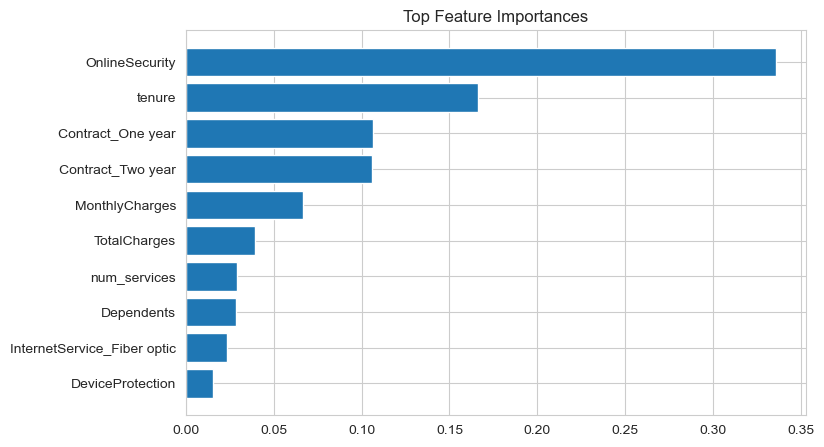

In [54]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Feature Importances")

plt.show()

#  Step 8: Pipeline, Deployment & GitHub Submission



## 8.1  Save the Final Pipeline

In [55]:
from sklearn.pipeline import Pipeline
import joblib

# Create Pipeline
pipeline = Pipeline([("model", dt)])

# Save Pipeline
joblib.dump(pipeline, "churn_model.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [56]:
import joblib

loaded_model = joblib.load("churn_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [57]:
# Take first 5 customers from test set
sample = X_test.head(5)

# Prediction
pred = loaded_model.predict(sample)

# Probability
prob = loaded_model.predict_proba(sample)

# Display Results
result = sample.copy()

result["Churn Probability"] = prob[:,1]
result["Prediction"] = pred

print(result[["Churn Probability","Prediction"]])

      Churn Probability  Prediction
974            0.000000           0
619            0.938826           1
4289           0.000000           0
3721           0.397321           0
4533           0.307692           0


In [58]:
for i in range(5):

    print(f"Customer {i+1}")

    print("Probability :", round(prob[i][1],3))

    print("Prediction  :", "Churn" if pred[i]==1 else "No Churn")

    print("-"*35)

Customer 1
Probability : 0.0
Prediction  : No Churn
-----------------------------------
Customer 2
Probability : 0.939
Prediction  : Churn
-----------------------------------
Customer 3
Probability : 0.0
Prediction  : No Churn
-----------------------------------
Customer 4
Probability : 0.397
Prediction  : No Churn
-----------------------------------
Customer 5
Probability : 0.308
Prediction  : No Churn
-----------------------------------
